<a href="https://colab.research.google.com/github/jiminAn/2023_SUMMER_SAMSUNG_DL/blob/main/%EC%8B%A4%EC%8A%B5%EC%9E%90%EB%A3%8C/Day4/Day_4_3_RNN_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN Basic
### Practice Goal
- Let's examine the input data format for an RNN model and define the model.

### Contents
1. Input data format of the RNN model
2. Define the RNN model
  1. vanila RNN
  2. LSTM


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")

## 1. Input Data Format for RNN Models

### Example: Let's use "hello" as input data for the RNN model.
![img.png](https://3863425935-files.gitbook.io/~/files/v0/b/gitbook-legacy-files/o/assets%2F-LIA3amopGH9NC6Rf0mA%2F-M4bJ-IWAKzglR0XHFwU%2F-M4bJ3KvyPXdSmZt6cU6%2Flanguage-model.png?generation=1586576265109629&alt=media)


In [ ]:
# Let's convert "hello" into vectors using one-hot encoding.

# one-hot vector / one-hot encoding / one-hot embedding

h = [1, 0, 0, 0]
e = [0, 1, 0, 0]
l = [0, 0, 1, 0]
o = [0, 0, 0, 1]


In [ ]:
input_data_np = np.array([[h, e, l, l, o]], dtype=np.float32) # Sequence Length 5 / Input Size 4
input_data = torch.Tensor(input_data_np)
input_data

- Using the vectors defined above, let's additionally convert "eolll" and "lleel" into vectors.

In [ ]:
# transform as torch tensor
input_data_np = np.array([[h, e, l, l, o],
                          [e, o, l, l, l],
                          [l, l, e, e, l]], dtype=np.float32)
input_data = torch.Tensor(input_data_np)
input_data.shape # (batch_size , sequence_length, input_size) (3, 5, 4)

In [ ]:
# (batch size, seq length(time step), input_size)
input_data.size()

### 2.1 Vanila RNN

#### `torch.nn.RNN(input_size, hidden_size, batch_first)`
- [pytorch document](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)
- `input_size`: The number of features in the input
- `hidden_size`: The size of the hidden state (usually set arbitrarily)
- `batch_first`: Determines whether the first dimension of the input shape should be treated as the batch size
  - True: (batch, seq, feature)
  - False: (seq, batch, feature)

In [ ]:
# declare dimension
input_size = 4
hidden_size = 3 #5 10

# declare RNN
rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)  # 처음에 batch_size or seq_length

In [ ]:
input_data

In [ ]:
# check output
outputs, _ = rnn(input_data)

# (batch_size x sequence length x input_size)

print("--------------Hidden states from all time steps-----------------")
print("outputs:\n", outputs)
print("outputs size:", outputs.size())  # Hidden states of dimension 3 from 5 time steps * 3 words
# shape: (3, 5, 3)
# (batch_size, seq_length, hidden_dim)

print("--------------Hidden state from the last time step-----------------")
print("hidden state:\n", outputs[:, -1, :])  # Hidden state at the last time step
print("hidden state size:", outputs[:, -1, :].size())
# shape: (1, 3, 3)
# (num_layers, batch_size, hidden_dim)

## 2.2 LSTM


#### `torch.nn.LSTM(input_size, hidden_size, batch_first)`
- [pytorch document](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)
- `input_size`: The number of features in the input
- `hidden_size`: The size of the hidden state (usually set arbitrarily)
- `batch_first`: Determines whether the first dimension of the input shape should be treated as the batch size
  - True: (batch, seq, feature)
  - False: (seq, batch, feature)

In [ ]:
lstm = torch.nn.LSTM(input_size, hidden_size, batch_first=True)
outputs, _status = lstm(input_data)
print(outputs)
print(outputs.size())
print()

print(_status[0]) # Last h_n
print(_status[0].shape)

print(_status[1]) # Last c_n
print(_status[1].shape)

## 2.3 GRU


In [ ]:
gru = torch.nn.GRU(input_size, hidden_size, batch_first=True)
outputs, _status = gru(input_data)
print(outputs)
print(outputs.size())
print()

print(_status[0])
print(_status[0].shape)

## 2.4 Bi-RNN (Bi-LSTM)
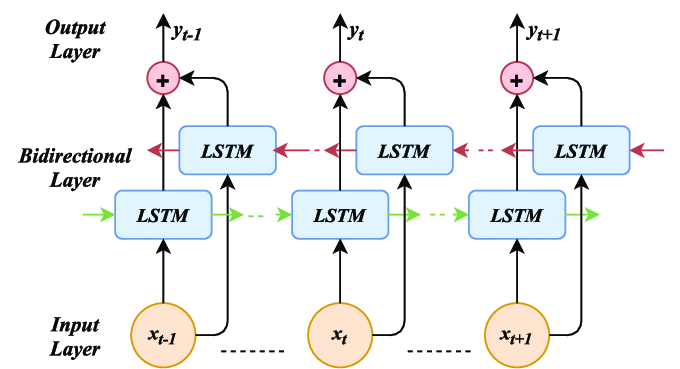

In [ ]:
# https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
bilstm = torch.nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
outputs, _status = bilstm(input_data)
print(outputs)
print(outputs.size())
print()

print(_status[0])
print(_status[0].shape)

## 3. Practical Example: Google Stock Price Prediction (Bi-LSTM)
Predicts upwards/downwards trend of Google stock price using a Bi-LSTM with dropout regularisation.

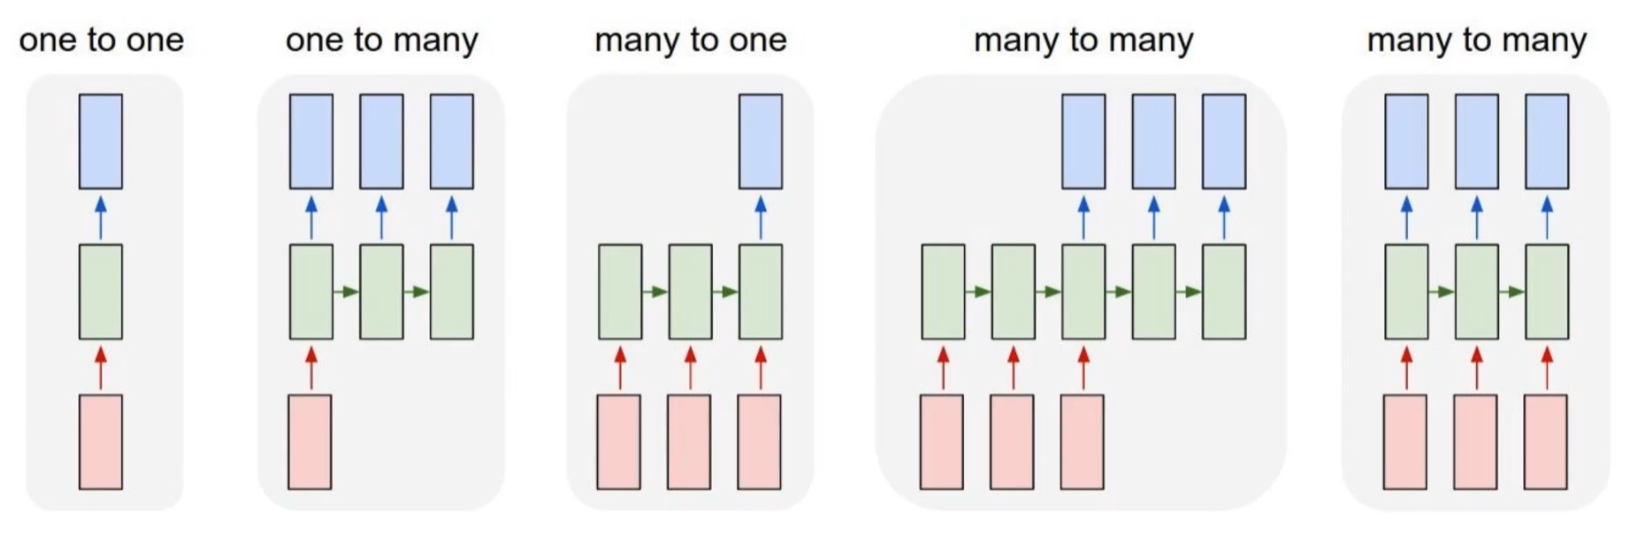

Part 1 - Data Preprocessing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Importing the training set
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')
training_set = dataset_train.iloc[:, 1:2].values

In [ ]:
dataset_train.head()

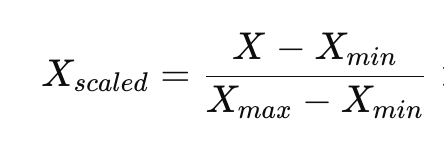

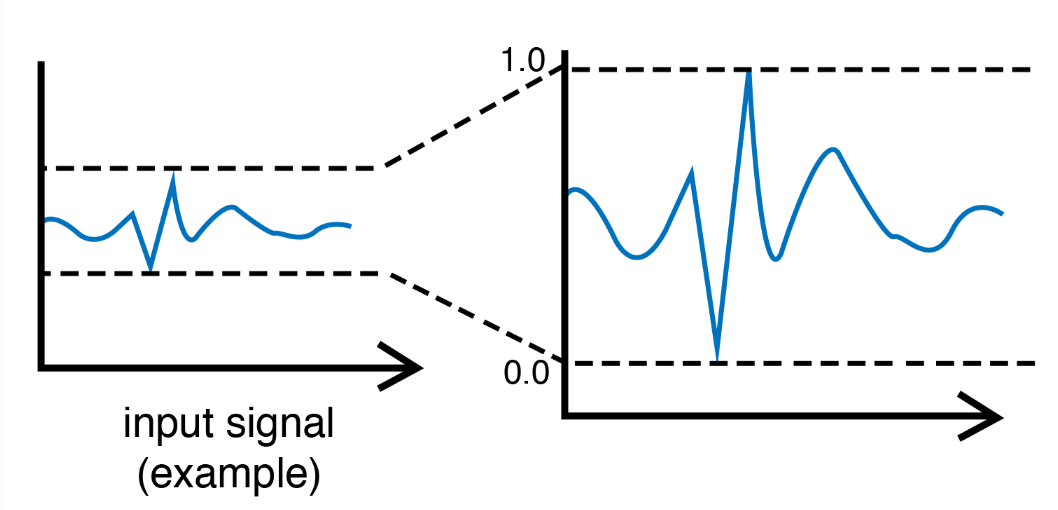

In [ ]:
# Feature Scaling (normalization to [0, 1])
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

## Let's predict the next day's stock price using the past 60 days of stock prices.

In [ ]:
# Creating a data structure with 60 timesteps and 1 output
X_train = []
y_train = []
for i in range(60, 1257):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
# Reshape to (batch, seq_len, input_size) for PyTorch LSTM with batch_first=True
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

Part 2 - Building the RNN
Bi-LSTM (2 layers, 50 hidden units, bidirectional) with dropout regularisation

In [ ]:
class Regressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        # bidirectional이면 출력 차원이 2 * hidden_size
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]      # 마지막 timestep, (batch, hidden_size * 2)
        out = self.dropout(out)
        return self.fc(out)

regressor = Regressor().to(device)

In [ ]:
# Compile equivalent: optimizer + loss
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(regressor.parameters())

In [ ]:
# Training loop
epochs = 200
regressor.train()
for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = regressor(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    print(f'Epoch {epoch}/{epochs} - loss: {epoch_loss:.6f}')

Part 3 - Making the predictions and visualising the results

In [ ]:
# Real stock price
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

In [ ]:
# Predicted stock price
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(60, 60 + len(dataset_test)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

regressor.eval()
with torch.no_grad():
    predicted_stock_price = regressor(X_test_t).cpu().numpy()
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

In [ ]:
# Visualising the results
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()